# 02 - Feature engineering without leakage

How a fight becomes a vector of numbers, and why each step is built that way. It reads the master table and the matchups written by [UFC_Pipeline](../UFC_Pipeline.ipynb).

1. The rule: only the past
2. One career, fight by fight
3. Small samples and shrinkage
4. From two fighters to one matchup
5. Checking for leakage
6. How much signal each feature carries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from ufc_rating import plotting
from ufc_rating.config import MASTER_CSV, MATCHUPS_CSV
from ufc_rating.models.training import temporal_split
from ufc_rating.processing.features import (
    STATS_FEATURES, appearances, build_matchups, pre_fight_features,
)
from ufc_rating.processing.master import read_master

plotting.setup()
master = read_master(MASTER_CSV)
matchups = pd.read_csv(MATCHUPS_CSV, parse_dates=['date'])

## 1. The rule: only the past

A prediction for a fight on date *D* may only use what was known before *D*. The pipeline enforces it in one place (`fighter_states` in `src/ufc_rating/processing/features.py`):

1. Each fight is split into two rows, one per fighter, with their own numbers and their opponent's (to measure defence).
2. Per fighter and in date order, the raw counts are **cumulated**: fights, wins, minutes, strikes landed and absorbed, takedowns...
3. The cumulated state is kept once per date, then **shifted by one date**. A fighter's state before *D* is their state after their previous fight date.

Working per date rather than per fight matters for the 1990s tournaments, where one fighter could fight two or three times in a night: the second bout must not know the result of the first. Career ratios (win rate, strikes per minute...) are computed from the cumulated counts, so a five-minute fight weighs five minutes, not "one fight".

## 2. One career, fight by fight

Islam Makhachev's UFC career. Every row is the state **before** the fight on that line: it only reflects the rows above it.

In [2]:
pre = pre_fight_features(master)
apps = appearances(master)

fighter = apps.loc[apps['fighter_name'] == 'Islam Makhachev', 'fighter_id'].iloc[0]
career = apps[apps['fighter_id'] == fighter][['date', 'opponent_id', 'result', 'method_group']]
names = apps.drop_duplicates('fighter_id').set_index('fighter_id')['fighter_name']
career['opponent'] = career['opponent_id'].map(names)
state = pre.loc[fighter][['n_fights', 'win_rate', 'slpm', 'td_per15', 'streak', 'elo']]
career = career.merge(state, left_on='date', right_index=True)

(career[['date', 'opponent', 'result', 'method_group', 'n_fights', 'win_rate', 'slpm', 'td_per15', 'streak', 'elo']]
 .assign(date=lambda d: d['date'].dt.date)
 .round({'win_rate': 2, 'slpm': 2, 'td_per15': 2, 'elo': 0})
 .reset_index(drop=True))

,date,opponent,result,method_group,n_fights,win_rate,slpm,td_per15,streak,elo
0,2015-05-23,Leo Kuntz,win,Submission,0.0,NaN,NaN,NaN,0.0,1500.0
1,2015-10-03,Adriano Martins,loss,KO/TKO,1.0,0.67,3.73,2.98,1.0,1516.0
2,2016-09-17,Chris Wade,win,Decision,2.0,0.50,3.63,2.77,-1.0,1501.0
3,2017-02-11,Nik Lentz,win,Decision,3.0,0.60,2.55,3.24,1.0,1519.0
4,2018-01-20,Gleison Tibau,win,KO/TKO,4.0,0.67,2.64,3.72,2.0,1538.0
5,2018-07-28,Kajan Johnson,win,Submission,5.0,0.71,2.65,3.66,3.0,1555.0
6,2019-04-20,Arman Tsarukyan,win,Decision,6.0,0.75,2.56,3.62,4.0,1571.0
7,2019-09-07,Davi Ramos,win,Decision,7.0,0.78,2.23,3.70,5.0,1584.0
8,2021-03-06,Drew Dober,win,Submission,8.0,0.80,2.34,3.08,6.0,1598.0
9,2021-07-17,Thiago Moises,win,Submission,9.0,0.82,2.22,3.17,7.0,1613.0


- The first line has no history: 0 fights, Elo 1500, and no rates yet. Fights like this one (a debut on either side) are excluded from the training data.
- The 2015 knockout loss shows up one line later, in the streak and the Elo.
- The career rates start close to the UFC average and move towards the fighter's own style as minutes accumulate. That is the shrinkage of the next section.

## 3. Small samples and shrinkage

A raw rate computed on a few minutes is noise. A fighter who wins a debut by knockout in 20 seconds after landing 5 strikes "lands 15 strikes per minute".

Each ratio is therefore shrunk towards the UFC-wide average, as if every fighter started with one average 15-minute fight on their record:

$$\text{rate} = \frac{\text{count} + \text{prior rate} \times 15}{\text{minutes} + 15}$$

The prior fades as real minutes accumulate. Accuracies and defences get the same treatment with a prior worth about one fight of attempts, win and finish rates with two average fights.

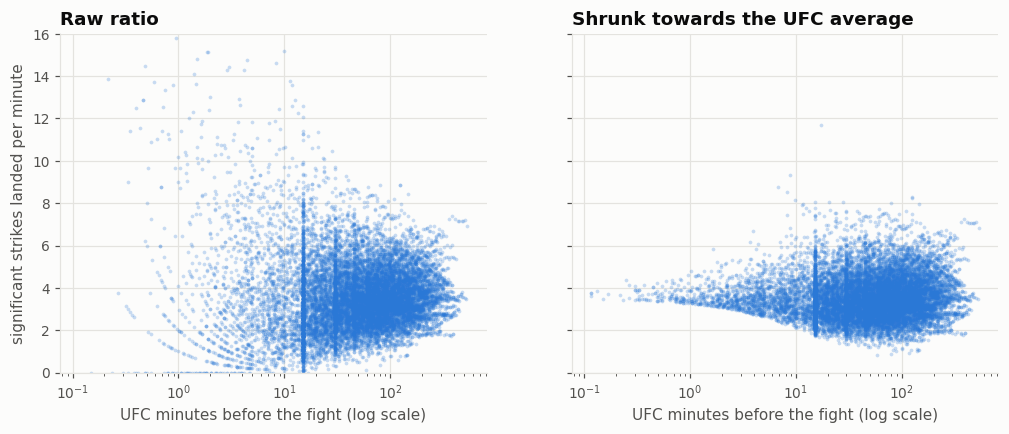

Raw rate above 10 per minute: 141 fighter-fights; after shrinkage: 1


In [3]:
# Raw cumulated counts before each fight date, next to the shrunk rate used by the models
counts = apps[['fighter_id', 'date']].assign(
    minutes=apps.groupby('fighter_id')['minutes'].cumsum(),
    landed=apps.groupby('fighter_id')['sig_landed'].cumsum())
raw = counts.drop_duplicates(['fighter_id', 'date'], keep='last').set_index(['fighter_id', 'date'])
raw = raw.groupby(level='fighter_id').shift(1).dropna()
raw['raw_slpm'] = raw['landed'] / raw['minutes']
raw['shrunk_slpm'] = pre.loc[raw.index, 'slpm']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, column, title in zip(axes, ['raw_slpm', 'shrunk_slpm'], ['Raw ratio', 'Shrunk towards the UFC average']):
    ax.scatter(raw['minutes'], raw[column], s=6, alpha=0.25, color=plotting.BLUE, linewidths=0)
    ax.set_xscale('log')
    ax.set_title(title)
    ax.set_xlabel('UFC minutes before the fight (log scale)')
axes[0].set_ylabel('significant strikes landed per minute')
axes[0].set_ylim(0, 16)
plt.show()
print(f"Raw rate above 10 per minute: {(raw['raw_slpm'] > 10).sum()} fighter-fights; "
      f"after shrinkage: {(raw['shrunk_slpm'] > 10).sum()}")

Left, the funnel of noise: extreme values only exist at a few minutes of experience. Right, the same data after shrinkage: short careers are pulled towards the average, long careers keep their own rate.

## 4. From two fighters to one matchup

For each fight the pipeline draws fighter **A** at random from the two corners (fixed seed) and describes the fight by **A minus B** for every fighter feature. The target is 1 when A won.

Randomising matters because the raw `r` side is the winner in almost every pre-2010 fight (see [01_exploration](01_exploration.ipynb)). Keeping it would hand the models a shortcut that has nothing to do with fighting.

In [4]:
print(f"{len(matchups):,} matchups, {len(STATS_FEATURES)} features")
print(f"Target if A were the first-listed fighter: {matchups.assign(r_won=lambda d: np.where(d['a_is_r'], d['a_wins'], 1 - d['a_wins']))['r_won'].mean():.1%} wins")
print(f"Target with A drawn at random: {matchups['a_wins'].mean():.1%} wins")

groups = {
    'career record': ['n_fights', 'win_rate', 'finish_rate', 'ko_rate', 'sub_rate', 'finished_rate',
                      'recent_win_rate', 'streak', 'days_since_last'],
    'striking': ['slpm', 'sapm', 'sig_acc', 'sig_def', 'kd_per15'],
    'grappling': ['td_per15', 'td_acc', 'td_def', 'sub_per15', 'ctrl_pct'],
    'physical': ['age', 'height_cm', 'reach_cm', 'southpaw'],
    'rating': ['elo'],
}
pd.DataFrame([(group, ', '.join(features)) for group, features in groups.items()],
             columns=['group', 'features (each used as A minus B)']).set_index('group')

6,525 matchups, 24 features
Target if A were the first-listed fighter: 61.8% wins
Target with A drawn at random: 49.5% wins


,features (each used as A minus B)
group,
career record,"n_fights, win_rate, finish_rate, ko_rate, sub_..."
striking,"slpm, sapm, sig_acc, sig_def, kd_per15"
grappling,"td_per15, td_acc, td_def, sub_per15, ctrl_pct"
physical,"age, height_cm, reach_cm, southpaw"
rating,elo


Differences make every feature **antisymmetric**: swapping A and B flips its sign. Missing differences are imputed with 0 ("no known difference") and the features are scaled without being centred, so the logistic regression, fitted without an intercept, gives exactly P(A beats B) = 1 - P(B beats A). The betting odds, used by the "stats + odds" models only, enter the same way as the log-odds of A's implied probability.

In [5]:
missing = matchups[STATS_FEATURES + ['odds_logit']].isna().mean()
missing[missing > 0].sort_values(ascending=False).map('{:.1%}'.format).to_frame('missing')

,missing
odds_logit,21.0%
delta_reach_cm,5.7%
delta_age,0.3%
delta_recent_win_rate,0.3%
delta_southpaw,0.2%
delta_height_cm,0.0%


## 5. Checking for leakage

If a feature used any information from the future, removing the future would change it. The matchups are rebuilt from the fights up to 2018 only, and compared with the full build on the fights they share. The same check runs in the test suite (`tests/test_features.py`).

In [6]:
cutoff = pd.Timestamp('2018-01-01')
truncated = build_matchups(master[master['date'] <= cutoff]).set_index('fight_id')
full = matchups.set_index('fight_id').loc[truncated.index]

max_gap = (full[STATS_FEATURES] - truncated[STATS_FEATURES]).abs().max().max()
print(f'{len(truncated):,} fights before {cutoff.date()}: largest difference between the two builds = {max_gap:.2e}')

3,040 fights before 2018-01-01: largest difference between the two builds = 2.84e-14


The features of a 2017 fight are identical whether or not the data after 2018 exists.

## 6. How much signal each feature carries

Each feature on its own, on the training period only: the AUC of "A wins when the feature is positive". 0.5 means no signal. Features whose AUC is below 0.5 are flipped and marked as such (a larger value predicts a *loss*).

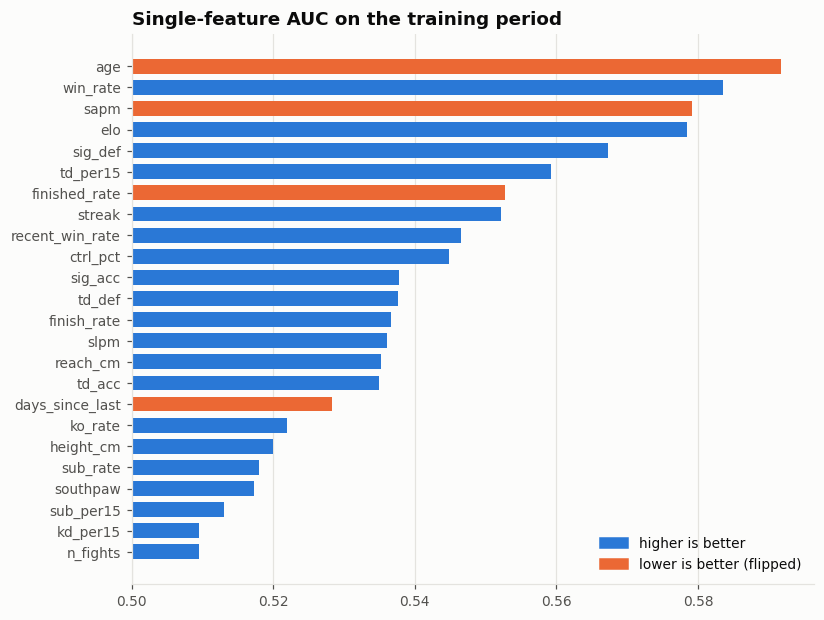

In [7]:
train, _, _ = temporal_split(matchups)
rows = []
for feature in STATS_FEATURES:
    values = train[feature].fillna(0)
    auc = roc_auc_score(train['a_wins'], values)
    rows.append({'feature': feature.removeprefix('delta_'), 'auc': max(auc, 1 - auc),
                 'direction': 'higher is better' if auc >= 0.5 else 'lower is better'})
signal = pd.DataFrame(rows).sort_values('auc')

colors = [plotting.BLUE if d == 'higher is better' else plotting.ORANGE for d in signal['direction']]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(signal['feature'], signal['auc'] - 0.5, left=0.5, color=colors, height=0.7)
ax.axvline(0.5, color=plotting.NEUTRAL, linewidth=1)
ax.set_xlim(0.5, None)
ax.set_title('Single-feature AUC on the training period')
ax.grid(axis='y', visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (plotting.BLUE, plotting.ORANGE)]
ax.legend(handles, ['higher is better', 'lower is better (flipped)'], loc='lower right')
plt.show()

- The strongest single signals are **age** (the younger fighter wins more often), **career win rate**, **strikes absorbed per minute** and **Elo**, followed by striking defence and takedown volume.
- Defence says more than offence: absorbing few strikes (`sapm`, `sig_def`) is a better sign than landing many (`slpm`, `sig_acc`).
- Being older, absorbing more strikes, having been finished more often and coming back from a long layoff all predict a loss.
- Even the best feature only reaches an AUC of about 0.59 on its own: the models get their accuracy from combining many weak signals.
- Many features overlap (win rate, streak and Elo all describe winning). The next chart shows how much.

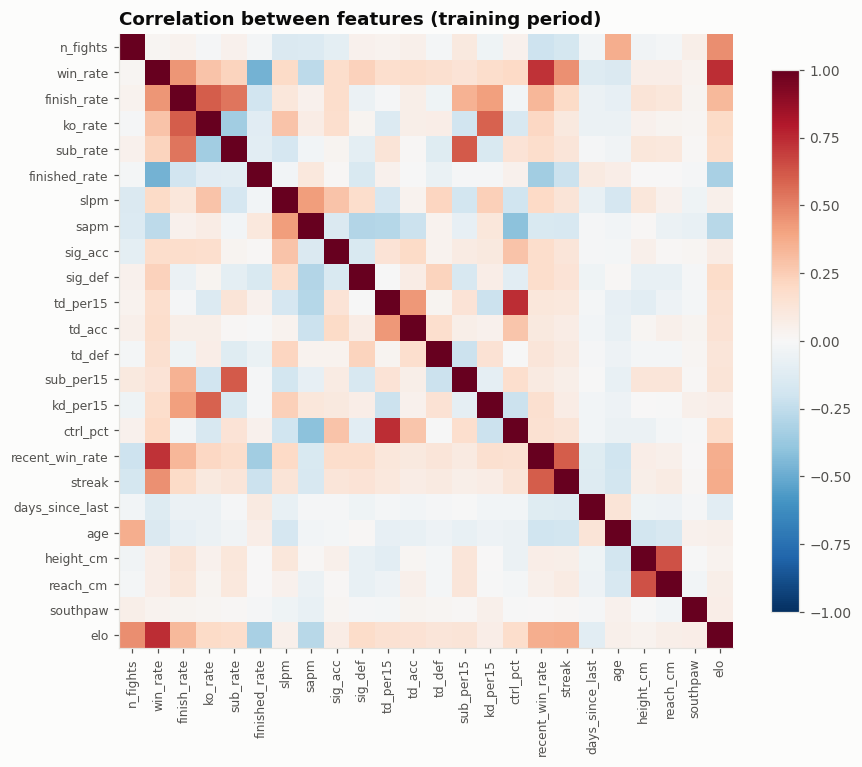

In [8]:
labels = [f.removeprefix('delta_') for f in STATS_FEATURES]
corr = train[STATS_FEATURES].corr().to_numpy()

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.grid(False)
ax.set_title('Correlation between features (training period)')
fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

Three blocks stand out: the **record** (win rate, recent form, streak and Elo), the **finishing profile** (knockout rate with knockdowns, submission rate with submission attempts) and **grappling** (takedowns with control time). The models cope with this redundancy in their own ways: the regularised logistic regression spreads the weight across correlated features, and the tree ensembles pick among them. [03_models_and_rankings](03_models_and_rankings.ipynb) shows what each model ends up relying on.